In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings("ignore")
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime

(Nice summary borrowed from Julien)

Analysis of the MRCCSN data, looking for angular crossings between $\nu_e$ and $\bar{\nu}_e$, with three criterions:
* the "sign-crossing" criterion (find a better name), which assumes that distributions are exactly the combination of a free-streaming ($f=1$) and trapped ($f=0$) component ;
* the polynomial criterion, which can be recasted as $f_\mathrm{ELN} \geq 1$ ;
* the Maximum Entropy criterion (see https://arxiv.org/pdf/2206.08444) ;

In [54]:
# Initial file setup/config
filename = "/lustre/isaac24/scratch/cellio18/projects/MRSN/sims/BH1/BH1_50ms/pw1/fluid_00001.h5"
root_dirname=filename.split("pw1")[0]
sim_dirname=filename.split("fluid")[0]
sim_name = filename.split("/")[9]

cmap_val = 'cividis'


In [18]:
# Analyze necessary MC distribution function parameters (using moments) to perform crossing tests. 

def extract_data(datafile):
    f = h5py.File(datafile, "r")
    # Read in distribution functions for nu_e (0) , nu_ebar (1)
    # Take slice across y = 0 plane 
    dist0 = np.array(f["distribution0(erg|ccm,tet)"][:,62,:,:,0:4])
    dist1 = np.array(f["distribution1(erg|ccm,tet)"][:,62,:,:,0:4])

    # Build energy bin array
    energy = np.array(f["axes/frequency(Hz)[mid]"]) * (6.626e-27)

    # Build number density moment summing over energies for xz spatial coordinates, regarding the previously taken y=0 plane slice. 
    # Shape (124, 63)
    ndens0 = np.sum((np.array(dist0)[ :, :, :, 0])/(energy[None, None, :]), axis=2)
    ndens1 = np.sum((np.array(dist1)[ :, :, :, 0])/(energy[None, None, :]), axis=2)

    # Build flux number density moment vector, one component for each cartesian spatial direction. Shape (124, 63, 3)
    f0 = np.sum((np.array(dist0)[:, :, :, 1:4])/(energy[None, None, :, None]), axis=2)
    f1 = np.sum((np.array(dist1)[:, :, :, 1:4])/(energy[None, None, :, None]), axis=2)

    fmag0= np.sqrt(np.sum(f0**2, axis=2))
    fmag1= np.sqrt(np.sum(f1**2, axis=2))

    # TODO Add comments
    num_free0 = fmag0
    num_free1 = fmag1

    num_trap0 = ndens0 - num_free0
    num_trap1 = ndens1 - num_free1

    eln_free = num_free0 - num_free1
    eln_trap = num_trap0 - num_trap1


    # Build each pressure number density moment, in total a 9 element-matrix
    # We build them as row vectors that compose the tensor
    # num_Px0 = np.sum((np.array(dist0)[:,62,:,:,4:7])/(energy[None, None, :, None]), axis=2)
    # num_Px1 = np.sum((np.array(dist1)[:,62,:,:,4:7])/(energy[None, None, :, None]), axis=2)

    # num_Py0 = np.sum((np.array(dist0)[:,62,:,:,7:10])/(energy[None, None, :, None]), axis=2)
    # num_Py1 = np.sum((np.array(dist1)[:,62,:,:,7:10])/(energy[None, None, :, None]), axis=2)

    # num_Pz0 = np.sum((np.array(dist0)[:,62,:,:,10:13])/(energy[None, None, :, None]), axis=2)
    # num_Pz1 = np.sum((np.array(dist1)[:,62,:,:,10:13])/(energy[None, None, :, None]), axis=2)

    # First moment: number density differences
    eln_ndens = ndens0 - ndens1
    ratio = (ndens0 - ndens1)/(ndens1 + ndens0)
    eln_sign = np.sign(eln_free*eln_trap)

    # Second moment: flux differences
    eln_flux = f0 - f1
    f0_mag = np.sqrt(np.sum(f0**2, axis=2))
    f1_mag = np.sqrt(np.sum(f1**2, axis=2))
    f0_fluxfac = f0_mag / ndens0
    f1_fluxfac = f1_mag / ndens1
    eln_flux_mag = np.sqrt(np.sum(eln_flux **2, axis=2))

    # Define flux factor using the magnitude of flux vector
    eln_flux_fac = eln_flux_mag / eln_ndens
    
    # correction to flux factor condition
    sign_eln_flux_fac = eln_flux_fac - 1
    
    data = {
        "n_ve": ndens0,
        "n_va": ndens1,
        "eln_free": eln_free,
        "eln_trap": eln_trap,
        "eln_n": eln_ndens,
        "sign_eln_n": eln_sign,
        "f_ve": f0,
        "f_ve_mag": f0_mag,
        "f_va_mag": f1_mag,
        "f_va": f1,
        "ffac_ve": f0_fluxfac,
        "ffac_va": f1_fluxfac,
        "eln_flux": eln_flux_fac,
        "sign_eln_flux": sign_eln_flux_fac,
    }
    
    return data 

In [4]:
# parent class for crossing criteria using distribution function moments

class ELNCrossingCriterion:
    def __init__(self, data, cmap_val="seismic"):
        self.name = None
        self.detect_crossing = False
        self.data = data 
        self.cmap_val = cmap_val
        
    def check_crossings(self):
        """Return boolean mask or result indicating where the criterion is satisfied"""
        raise NotImplementedError

    def plot(self, X, Z, cmap_val=cmap_val, ax=None, **kwargs):
        """Optional plotting of the diagnostic"""
        raise NotImplementedError

In [5]:
# Test 1 of 3: Sign Change test 

class ELNCrossing_Sign(ELNCrossingCriterion):
    def __init__(self, data, cmap_val):
        super().__init__(data)
        self.name = "Sign"
        self.data = data
        self.detect_crossing = False
        self.cmap_val = cmap_val

    def crossing_check(self):
        # sign change in number density test / direct search
        # we evaluate the difference in number densities of the e/anti-e flavors and 
        # examine the sign change of this difference throughout the domain
        
        if np.any(self.data < 0):
            self.detect_crossing = True
        else:
            pass
        return (f"Crossings found in file using Julien's sign change criterion: {self.detect_crossing}")
        
    def plot(self, X, Z, ax=None, **kwargs):
        # Take optional figure argument and draw into it if given; if not, create new 
        if ax is None:
            fig, ax = plt.subplots()
        mesh = ax.pcolormesh(X, Z, self.data, shading='auto', cmap=self.cmap_val, label='ELN Sign')
        ax.set_title("Julien's Criterion;\n sign[(nν_e(trap) - nν̄_e(trap))*((nν_e(free) - nν̄_e(free))]")
        ax.set_ylabel("x (km)")
        ax.set_xlabel("z (km)")
        return mesh

In [6]:
# Test 2 of 3: Flux Factor Test

class ELNCrossing_Polynomial(ELNCrossingCriterion):
    def __init__(self, data, cmap_val):
        super().__init__(data)
        self.name = "Polynomial"
        self.data = data
        self.detect_crossing = False
        self.cmap_val = cmap_val

    def crossing_check(self):
        # From arXiv:2206.08444v3: "The polynomial test of [52] states that if two different positive-weighted angular integrals of the ELN distribution
        # G(Ω) have opposite sign, then the ELN itself must carry positive and negative values. thus, a crossing must occur."
        # In simpler terms, if the ELN flux factor is greater than 1 in some regions of the domain, then the distribution function must be non-positive in some part of the domain. 
        if np.any(abs(self.data) > 1):
            self.detect_crossing = True
        else:
            pass
        return (f"ELN Flux Factor Crossings Predicted? {self.detect_crossing}")

    def plot(self, X, Z, ax=None, **kwargs):
        # Take optional figure argument and draw into it if given; if not, create new  
        if ax is None:
            fig, ax = plt.subplots()
        mesh = ax.pcolormesh(X, Z, self.data, shading='auto', cmap=self.cmap_val, vmin=-1.2, vmax=1.2)
        # smoothed_data = gaussian_filter(self.data, sigma=1.75)
        contour = ax.contour(X, Z, self.data, levels=[-1, 1], colors='black')
        ax.clabel(contour, inline=True, fontsize=10)
        ax.set_title("Polynomial Test;\nCrossings |f_eln| > 1")
        ax.set_xlabel("z (km)")
        return mesh

In [7]:
# Test 3 of 3: Maximum Entropy Closure Test

class ELNCrossing_MEC(ELNCrossingCriterion):
    def __init__(self, data, cmap_val):
        super().__init__(data)
        self.name = "MEC"
        self.data = data
        self.detect_crossing = False
        self.cmap_val = cmap_val
        
    def get_Z_approxbis(self, fluxfac):
        
        # When assuming maximum entropy closure of the distribution function,
        # we get f = coth(Z) - 1/Z where Z is some parameter.
        
        # A few ways to approximate Z: 
        # either by taylor expansion of the Langevin function, Pade approximation, or complex approx.
        # Expression by Jedynak https://www.sciencedirect.com/science/article/pii/S0377025717302525
        #TODO Julien says using p method not the best route? Introduce numerical error? 
        
        p = 1 - (2*(1-fluxfac)*(1+1.01524*fluxfac))/(3 - 1.00651*fluxfac**2 - 0.962251*fluxfac**4 + 1.47353*fluxfac**6 - 0.48953*fluxfac**8)
        return (2*fluxfac)/(1-p)
    
    def get_crossingcriterion(self):
        # After using method above to approx. Z, we can find the angle such that the condition of a crossing is met:
        # we end up with an expression (after some angle identity exploitation):
        # The condition for instability is η^2/(α^2 + γ^2) ≤ 1 ." EQ 14-18 from arXiv:2206.08444v3
        # where theta is defined as the angle between net number flux of a given species, x: cosθ = Ω·Fx
        # e.g. usage: mec_test(ndens0, ndens1, fmag_0, fmag_1)
        
        # We need the following fluxes and components in order to evaluate eta, gamma, alpha
        f_va_x = self.data['f_va'][:,:,0]
        f_va_y = self.data['f_va'][:,:,1]
        f_va_z = self.data['f_va'][:,:,2]
        f_va_mag = self.data['f_va_mag']
        f_ve_x = self.data['f_ve'][:,:,0]
        f_ve_y = self.data['f_ve'][:,:,1]
        f_ve_z = self.data['f_ve'][:,:,2]
        f_ve_mag = self.data['f_ve_mag']
        
        
        Z_ve = self.get_Z_approxbis(self.data['ffac_ve'])
        Z_va = self.get_Z_approxbis(self.data['ffac_va']) 
        
        
        # page 6, under equation 16, "Evaluating..." (Richers)
        # Since the direction of theta is arbitrary, we can choose it to be along the z-axis.
        # therefore, sin(theta_Fi)=(sqrt(Fxi**2 + Fyi**2)/Fi_mag) & cos(theta_Fi) = Fzi/Fi_mag where i is some flavor
        
        eta   = np.log((self.data['n_ve'])*Z_ve*np.sinh(Z_va) / (self.data['n_va'])*Z_va*np.sinh(Z_ve))
        gamma = (Z_va*(f_va_z/f_va_mag)) - (Z_ve*(f_ve_z/f_ve_mag))
        alpha = (Z_va*np.sqrt(f_va_x**2 + f_va_y**2)/f_va_mag) - (Z_ve*np.sqrt(f_ve_x**2 + f_ve_y**2)/f_ve_mag)
        
        criterion = (eta**2/(alpha**2 + gamma**2) - 1)
        return criterion # unstable if criterion <= 0

    def crossing_check(self):
        
        criterion = self.get_crossingcriterion()
        if np.any(criterion <= 0):
            self.detect_crossing = True 
        else: 
            pass
        return(f"ME Closure Crossings? {self.detect_crossing}")
   
    def plot(self, X, Z, ax=None, **kwargs):
        # Take optional figure argument and draw into it if given; if not, create new 
        if ax is None:
            fig, ax = plt.subplots()
        mesh = ax.pcolormesh(X, Z, self.get_crossingcriterion(), shading='auto', cmap=self.cmap_val, label='MEC', vmin=-1, vmax=1)
        ax.set_title("MEC Criterion\n Crossings Possible for η^2/(α^2 + γ^2) - 1 ≤ 0")
        ax.set_xlabel("z (km)")
        return mesh

In [8]:
# BEGIN PLOTTING ROUTINE

# Set up grid for plotting

def plot_setup(data, reflevel="5"):
    # Define map for refinement level to physical grid cell dimension in cm
    grid_cell_map = {
        '4': 6e5,
        '5': 3e5,
        '6': 1.5e5,
    }

    # Set up grid using specific refinement level
    cell_size_cm = grid_cell_map[reflevel]
    nx, nz = data.shape
    # convert grid cells to km (simulation base units of cm)
    # the z axis is reflected, the x axis is not
    x_span_km = (np.arange(nx) - nx // 2) * (cell_size_cm / 1e5)
    z_span_km = (np.arange(nz) ) * (cell_size_cm / 1e5)
    print(x_span_km.shape, z_span_km.shape)
    # create grid out of length-based coordinates
    X_km, Z_km = np.meshgrid(x_span_km, z_span_km, indexing='ij')
    return X_km, Z_km

In [9]:
## all criteria plotting ## 
def compare_ffi_plots(criteria, X, Z, cmap_val):
    
    # fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(11,15), sharex=True)
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18,9.5), sharex=True)
    fig.suptitle(f"Search for ELN Crossings in MRCCSN using Relativistic Monte Carlo Radiation Transport\n {sim_name}, reflevel=5", fontsize=14, weight='bold')
    plt.subplots_adjust(wspace=0.4)
    
    axes = [ax1, ax2, ax3]
    meshes = []
    
    plt.xlabel(' z (km)')
    
    for i, criterion in enumerate(criteria):
        divider = make_axes_locatable(axes[i])
        cax = divider.append_axes('right', size='8%', pad=0.01)
        axes[i].set_aspect('equal')
        c = criterion.plot(X, Z, ax=axes[i])
        meshes.append(c)
        fig.colorbar(c, cax=cax, orientation='vertical')

    fig.patch.set_facecolor('white')
    return fig

In [10]:
## all criteria check ## 
def predict_ffi(criteria):
    
    for i, criterion in enumerate(criteria):
        print(criterion.crossing_check())

In [11]:
# Example usage for quick checking if crossings were found
data = extract_data(filename)


(320,) (181,)
Crossings found in file using Julien's sign change criterion: True
ELN Flux Factor Crossings Predicted? True
ME Closure Crossings? False


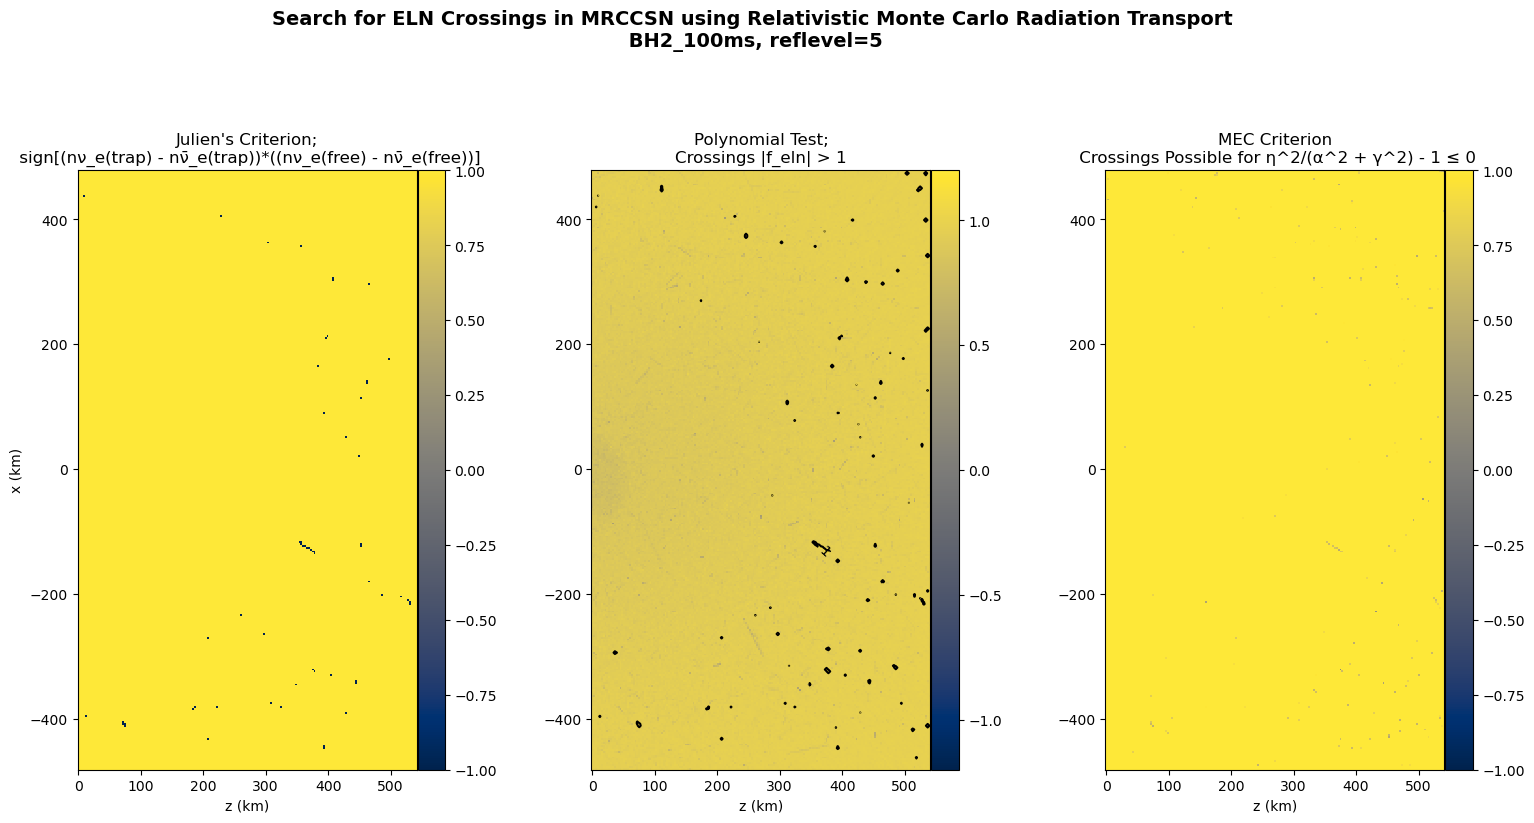

In [12]:
mec_keys = {'n_ve', 'n_va', 'f_ve', 'f_va', 'f_ve_mag', 'f_va_mag', 'ffac_ve', 'ffac_va'}
mec_data = {k: data[k] for k in mec_keys}
X_km, Z_km = plot_setup(data['eln_n'])

criteria = [
    ELNCrossing_Sign(data["sign_eln_n"], cmap_val),
    ELNCrossing_Polynomial(data["eln_flux"], cmap_val),
    ELNCrossing_MEC(mec_data, cmap_val),
]

predict_ffi(criteria)

now = datetime.now()


# Example usage for actually plotting the results of different tests. 
fig = compare_ffi_plots(criteria, Z_km, X_km, cmap_val=cmap_val)
plt.show()
fig.savefig(f'{root_dirname}/plots/compare_ffi_{now.strftime("%m%d%y_%H%M")}.png')
plt.close()

In [55]:
data = extract_data(filename)
X_km, Z_km = plot_setup(data['eln_n'], reflevel='6')


(320,) (191,)


In [46]:
# print(data["n_va"].shape)
# i = data["n_va"].shape[0]//2
# print(i)
# j = 0
# print(data["n_va"][i][j], data["n_ve"][i][j])
# print(data["ffac_va"][i][j], data["ffac_ve"][i][j])
# print(data["eln_free"][i][j], data["eln_trap"][i][j])

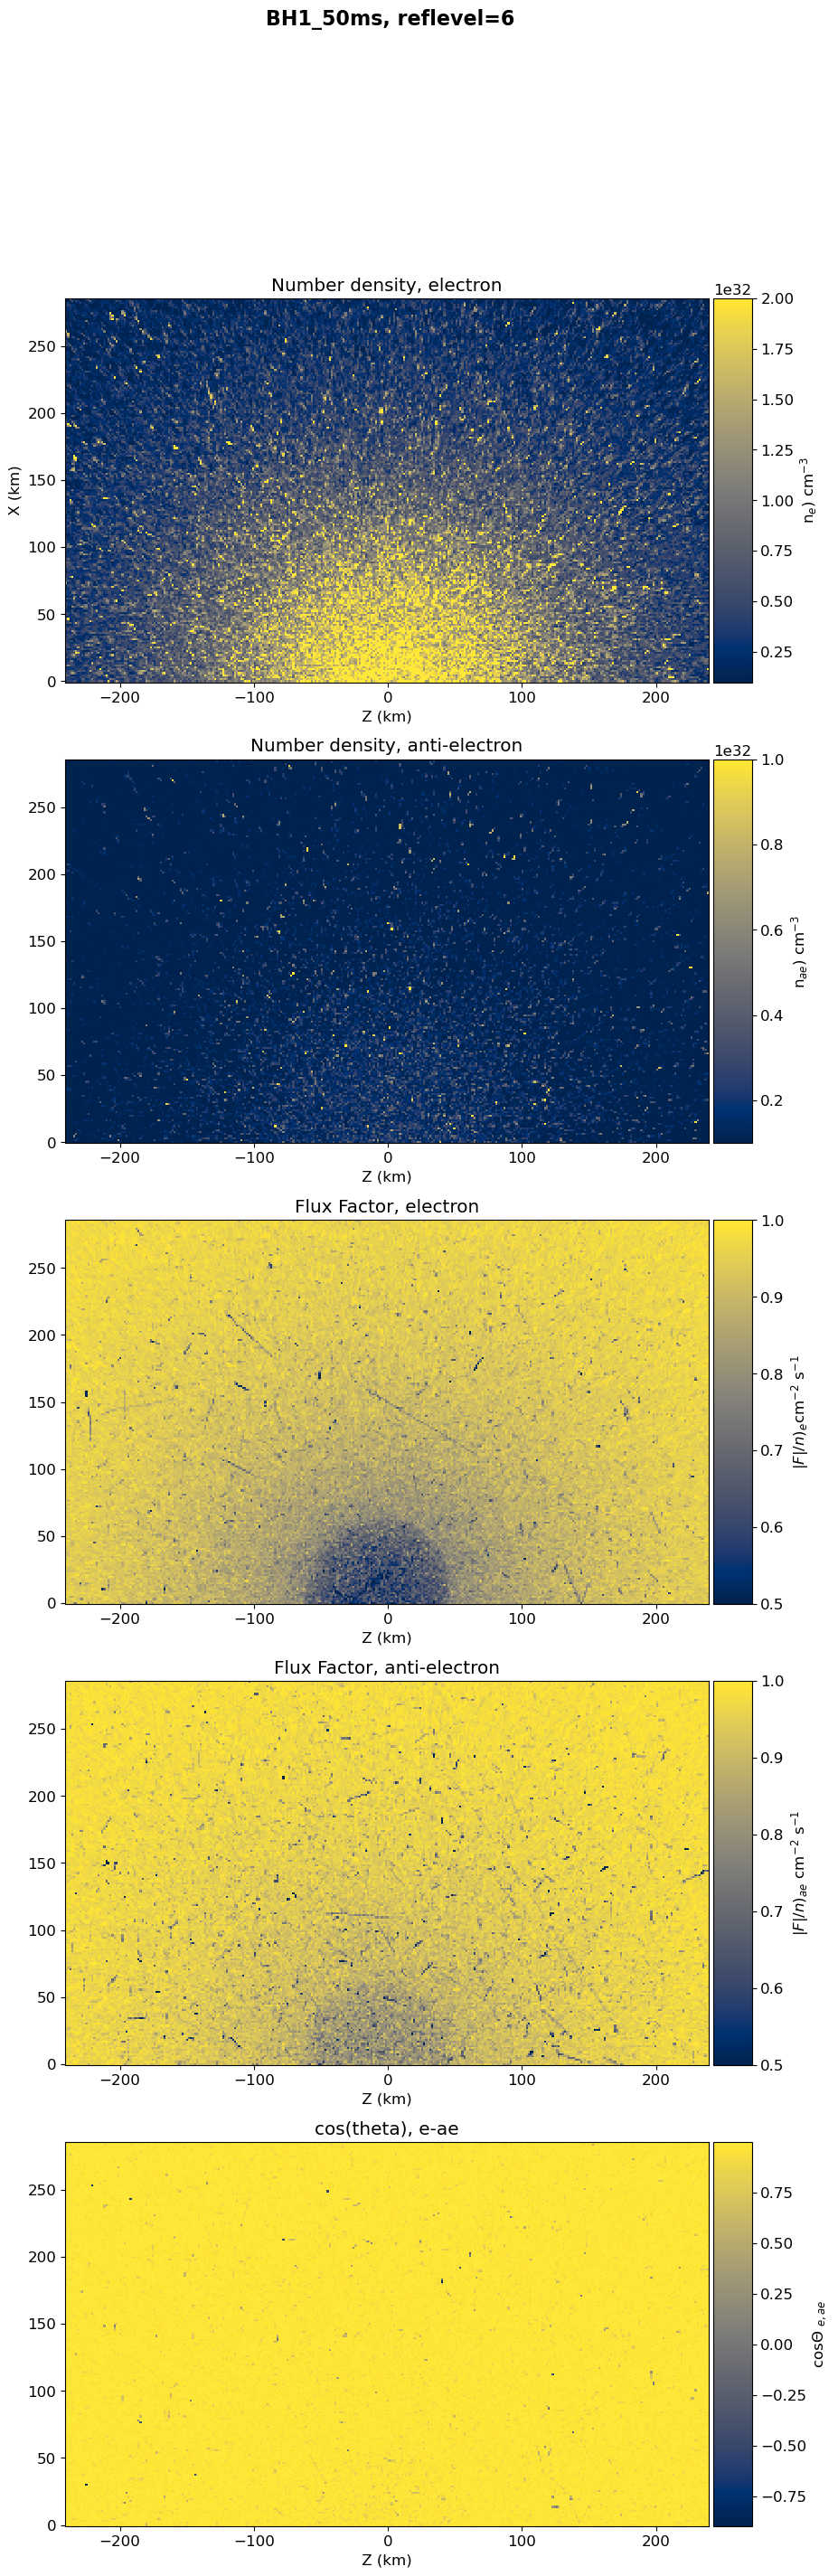

In [56]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(16,32))
ax1, ax2, ax3, ax4, ax5 = axes.flatten()

plt.rcParams['font.size'] = 12
plt.subplots_adjust(wspace=0.25)

cos_theta = np.divide(np.sum(data["f_ve"] * data["f_va"], axis = 2),  data['f_va_mag'] * data['f_ve_mag'])

mesh1 = ax1.pcolormesh(X_km, Z_km, data['n_ve'], vmin=1e31, vmax=2e32, shading='auto', cmap="cividis")
mesh2 = ax2.pcolormesh(X_km, Z_km, data['n_va'], vmin=1e31, vmax=1e32, shading='auto', cmap="cividis")
mesh3 = ax3.pcolormesh(X_km, Z_km, data['ffac_ve'], vmin=0.5, vmax=1, shading='auto', cmap="cividis")
mesh4 = ax4.pcolormesh(X_km, Z_km, data['ffac_va'], vmin=0.5, vmax=1, shading='auto', cmap="cividis")
mesh5 = ax5.pcolormesh(X_km, Z_km, cos_theta, shading='auto', cmap="cividis")

meshes = [mesh1, mesh2, mesh3, mesh4, mesh5]
cbar = []

fig.suptitle(f"{sim_name}, reflevel=6", fontsize=16, weight='bold')

for i, ax in enumerate(axes.flatten()):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='6%', pad=0.05)
    ax.set_aspect('equal')
    cbar.append(fig.colorbar(meshes[i], cax=cax, orientation='vertical'))
    ax.set_xlabel(" Z (km) " )

(axes[0]).set_ylabel(" X (km) ")

ax1.set_title("Number density, electron")
ax2.set_title("Number density, anti-electron")
ax3.set_title("Flux Factor, electron")
ax4.set_title("Flux Factor, anti-electron")
ax5.set_title("cos(theta), e-ae")

cbar[0].set_label("n$_{e}$) cm$^{-3}$")
cbar[1].set_label("n$_{ae}$) cm$^{-3}$")
cbar[2].set_label("$|F|/n$)$_{e}$cm$^{-2}$ s$^{-1}$")
cbar[3].set_label("$|F|/n$)$_{ae}$ cm$^{-2}$ s$^{-1}$")
cbar[4].set_label("cos$\Theta$ $_{e,ae}$")

fig.patch.set_facecolor('white')
plt.show()
fig.savefig(f'{root_dirname}/plots/diagnostics_{sim_name}.png')
plt.close()